In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Path of Breast Cancer CSV file
file_path = "C:/Users/Kandarp Malkan/OneDrive/Desktop/DL_Material/breast-cancer.csv"
# file_path = "Z:/brest-cancer.csv" FOR THE LAB/ EXAM ENVIRONMENT

# Load CSV file
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset Shape: (569, 31)

Columns:
Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [4]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

print(df["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [5]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [6]:
X = X.apply(pd.to_numeric, errors="coerce")

# Remove rows containing missing values
X = X.dropna()

# Keep target values corresponding to remaining rows
y = y.loc[X.index]

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (569, 30)
Final y shape: (569,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [9]:
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),
    
    
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1984      
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dense_3 (Dense)             (None, 64)                4160      
                                                                 
 dense_4 (Dense)             (None, 64)                4160      
                                                                 
 dense_5 (Dense)             (None, 64)                4160      
                                                                 
 dense_6 (Dense)             (None, 64)                4

In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
12/12 [==============================] - 3s 68ms/step - loss: 0.6724 - accuracy: 0.6154 - val_loss: 0.6505 - val_accuracy: 0.6703
Epoch 2/10
12/12 [==============================] - 0s 7ms/step - loss: 0.6731 - accuracy: 0.6154 - val_loss: 0.6436 - val_accuracy: 0.6703
Epoch 3/10
12/12 [==============================] - 0s 10ms/step - loss: 0.6684 - accuracy: 0.6154 - val_loss: 0.6412 - val_accuracy: 0.6703
Epoch 4/10
12/12 [==============================] - 0s 14ms/step - loss: 0.6673 - accuracy: 0.6154 - val_loss: 0.6383 - val_accuracy: 0.6703
Epoch 5/10
12/12 [==============================] - 0s 11ms/step - loss: 0.6674 - accuracy: 0.6154 - val_loss: 0.6407 - val_accuracy: 0.6703
Epoch 6/10
12/12 [==============================] - 0s 9ms/step - loss: 0.6669 - accuracy: 0.6154 - val_loss: 0.6400 - val_accuracy: 0.6703
Epoch 7/10
12/12 [==============================] - 0s 8ms/step - loss: 0.6663 - accuracy: 0.6154 - val_loss: 0.6378 - val_accuracy: 0.6703
Epoch 8/10
12/12

In [12]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.6581198573112488
Test Accuracy: 0.6315789222717285


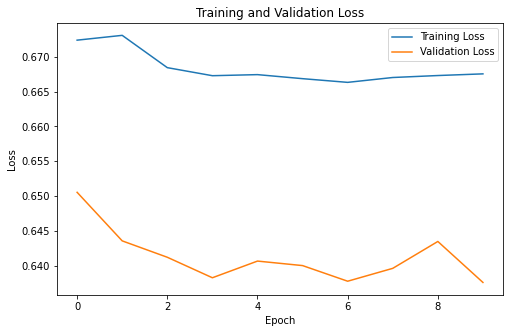

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()